# 🌿 Northern Israel — NDVI & Land Surface Temperature Data
**Project: Vegetation Health & Heat Stress Monitoring in the Galilee**

This notebook fetches:
- **NDVI** (Normalized Difference Vegetation Index) — how green/healthy is the vegetation?
- **LST** (Land Surface Temperature) — how hot is the ground surface?

Data source: NASA MODIS via Google Earth Engine
Region: Northern Israel (Galilee + valleys)
Time period: 2015–2025


## Step 1 — Install & Authenticate Google Earth Engine

In [ ]:
# Install required libraries
!pip install earthengine-api geemap -q

import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from datetime import datetime

print('Libraries loaded successfully!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 29.2 MB/s eta 0:00:00
Libraries loaded successfully!


In [ ]:
# Authenticate with your Google Earth Engine account
# A browser window will open — log in with your Google account
ee.Authenticate()
ee.Initialize(project='datanature')  # ← Replace with your GEE project ID
# If you don't have a project ID, use: ee.Initialize()
print('Google Earth Engine authenticated!')

Google Earth Engine authenticated!


## Step 2 — Define the Study Region (Northern Israel)

In [ ]:
# Define Northern Israel bounding box (Galilee + valleys)
# Covers: Upper Galilee, Lower Galilee, Jezreel Valley, Hula Valley, Jordan Valley
northern_israel = ee.Geometry.Rectangle([
    34.9,   # West longitude
    32.4,   # South latitude
    35.9,   # East longitude
    33.3    # North latitude
])

# Define key sub-regions as points for time-series extraction
locations = {
    'Upper_Galilee_Forest':   ee.Geometry.Point([35.25, 33.05]),
    'Jezreel_Valley_Agri':    ee.Geometry.Point([35.20, 32.65]),
    'Hula_Valley_Wetland':    ee.Geometry.Point([35.60, 33.07]),
    'Nazareth_Urban':         ee.Geometry.Point([35.30, 32.70]),
    'Carmel_Forest':          ee.Geometry.Point([35.03, 32.72]),
    'Jordan_Valley_Arid':     ee.Geometry.Point([35.55, 32.50]),
    'Haifa_Coastal_Urban':    ee.Geometry.Point([34.99, 32.82]),
    'Lower_Galilee_Mixed':    ee.Geometry.Point([35.40, 32.80]),
}

print(' Study region defined — Northern Israel (Galilee + valleys)')
print(f' {len(locations)} monitoring locations set')

 Study region defined — Northern Israel (Galilee + valleys)
 8 monitoring locations set


## Step 3 — Fetch NDVI Data (2000–2025)

In [ ]:
# Load MODIS NDVI dataset
# MOD13Q1: 16-day composite, 250m resolution
ndvi_collection = (
    ee.ImageCollection('MODIS/061/MOD13Q1')
    .filterDate('2000-02-18', '2025-12-31')
    .filterBounds(northern_israel)
    .select('NDVI')
)

print(f'NDVI dataset loaded')
print(f'Images found: {ndvi_collection.size().getInfo()}')
print(f'Resolution: 250 meters per pixel')
print(f'Cadence: every 16 days')

NDVI dataset loaded
Images found: 595
Resolution: 250 meters per pixel
Cadence: every 16 days


In [ ]:
# Extract NDVI time series for each location
def extract_timeseries(collection, point, scale=500):
    """Extract time series values at a specific point."""
    def extract_value(image):
        date = image.date().format('YYYY-MM-dd')
        value = image.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=point,
            scale=scale
        )
        return ee.Feature(None, value.set('date', date))

    features = collection.map(extract_value)
    return ee.FeatureCollection(features)

# Extract for all locations
print(' Extracting NDVI time series for all locations...')
print('   (This may take 1-2 minutes)')

ndvi_data = {}
for name, point in locations.items():
    fc = extract_timeseries(ndvi_collection, point)
    data = fc.getInfo()
    records = []
    for f in data['features']:
        props = f['properties']
        ndvi_raw = props.get('NDVI')
        if ndvi_raw is not None:
            records.append({
                'date': props['date'],
                'NDVI': ndvi_raw * 0.0001  # Scale factor
            })
    ndvi_data[name] = pd.DataFrame(records)
    print(f'    {name}: {len(records)} data points')

print('\n All NDVI data extracted!')

 Extracting NDVI time series for all locations...
   (This may take 1-2 minutes)
    Upper_Galilee_Forest: 595 data points
    Jezreel_Valley_Agri: 595 data points
    Hula_Valley_Wetland: 595 data points
    Nazareth_Urban: 595 data points
    Carmel_Forest: 595 data points
    Jordan_Valley_Arid: 595 data points
    Haifa_Coastal_Urban: 595 data points
    Lower_Galilee_Mixed: 595 data points

 All NDVI data extracted!


## Step 4 — Fetch Land Surface Temperature Data (2000–2025)

In [ ]:
# Load MODIS LST dataset
# MOD11A1: Daily LST, 1km resolution
lst_collection = (
    ee.ImageCollection('MODIS/061/MOD11A1')
    .filterDate('2000-01-01', '2025-12-31')
    .filterBounds(northern_israel)
    .select('LST_Day_1km')  # Daytime temperature
)

print(f' LST dataset loaded')
print(f' Images found: {lst_collection.size().getInfo()}')
print(f' Resolution: 1000 meters per pixel')
print(f' Cadence: daily')

 LST dataset loaded
 Images found: 9372
 Resolution: 1000 meters per pixel
 Cadence: daily


In [ ]:
# We'll use monthly composites to reduce data volume
def monthly_composite(collection, year, month):
    start = f'{year}-{month:02d}-01'
    end = f'{year}-{month:02d}-28'
    return collection.filterDate(start, end).mean()

# Extract monthly LST for all locations
print(' Extracting monthly LST time series...')
print('   (This may take 7-8 minutes)')

lst_data = {}
for name, point in locations.items():
    records = []
    for year in range(2000, 2026):
        for month in range(1, 13):
            if year == 2025 and month > 12:
                break
            try:
                img = monthly_composite(lst_collection, year, month)
                val = img.reduceRegion(
                    reducer=ee.Reducer.mean(),
                    geometry=point,
                    scale=1000
                ).get('LST_Day_1km').getInfo()
                if val is not None:
                    # Convert from Kelvin (scale 0.02) to Celsius
                    temp_celsius = (val * 0.02) - 273.15
                    records.append({
                        'date': f'{year}-{month:02d}-01',
                        'year': year,
                        'month': month,
                        'LST_Celsius': round(temp_celsius, 2)
                    })
            except:
                pass
    lst_data[name] = pd.DataFrame(records)
    print(f'    {name}: {len(records)} monthly records')

print('\n All LST data extracted!')

 Extracting monthly LST time series...
   (This may take 7-8 minutes)
    Upper_Galilee_Forest: 311 monthly records
    Jezreel_Valley_Agri: 311 monthly records
    Hula_Valley_Wetland: 311 monthly records
    Nazareth_Urban: 310 monthly records
    Carmel_Forest: 311 monthly records
    Jordan_Valley_Arid: 311 monthly records
    Haifa_Coastal_Urban: 311 monthly records
    Lower_Galilee_Mixed: 311 monthly records

 All LST data extracted!


## Step 5 — Build Combined Dataset

In [ ]:
# Combine NDVI and LST into one master dataframe
all_records = []

for name in locations.keys():
    # Get LST data (monthly)
    lst_df = lst_data[name].copy()
    lst_df['location'] = name
    lst_df['land_type'] = (
        'Forest' if 'Forest' in name
        else 'Agricultural' if 'Agri' in name
        else 'Wetland' if 'Wetland' in name
        else 'Urban' if 'Urban' in name
        else 'Arid' if 'Arid' in name
        else 'Mixed'
    )

    # Get monthly NDVI average
    ndvi_df = ndvi_data[name].copy()
    ndvi_df['date'] = pd.to_datetime(ndvi_df['date'])
    ndvi_df['year'] = ndvi_df['date'].dt.year
    ndvi_df['month'] = ndvi_df['date'].dt.month
    ndvi_monthly = ndvi_df.groupby(['year', 'month'])['NDVI'].mean().reset_index()

    # Merge
    merged = lst_df.merge(ndvi_monthly, on=['year', 'month'], how='left')
    all_records.append(merged)

master_df = pd.concat(all_records, ignore_index=True)
master_df['date'] = pd.to_datetime(master_df['date'])
master_df = master_df.sort_values(['location', 'date']).reset_index(drop=True)

print(' Master dataset created!')
print(f' Total records: {len(master_df)}')
print(f' Locations: {master_df["location"].nunique()}')
print(f' Date range: {master_df["date"].min().date()} → {master_df["date"].max().date()}')
print()
print(master_df.head(10))

 Master dataset created!
 Total records: 2487
 Locations: 8
 Date range: 2000-02-01 → 2025-12-01

        date  year  month  LST_Celsius       location land_type     NDVI
0 2000-02-01  2000      2        12.73  Carmel_Forest    Forest  0.51870
1 2000-03-01  2000      3        17.72  Carmel_Forest    Forest  0.54010
2 2000-04-01  2000      4        23.51  Carmel_Forest    Forest  0.54810
3 2000-05-01  2000      5        28.14  Carmel_Forest    Forest  0.45215
4 2000-06-01  2000      6        32.60  Carmel_Forest    Forest  0.41280
5 2000-07-01  2000      7        33.20  Carmel_Forest    Forest  0.38150
6 2000-08-01  2000      8        32.67  Carmel_Forest    Forest  0.36390
7 2000-09-01  2000      9        31.59  Carmel_Forest    Forest  0.38415
8 2000-10-01  2000     10        28.18  Carmel_Forest    Forest  0.40050
9 2000-11-01  2000     11        22.67  Carmel_Forest    Forest  0.49410


## Step 6 — Visualizations

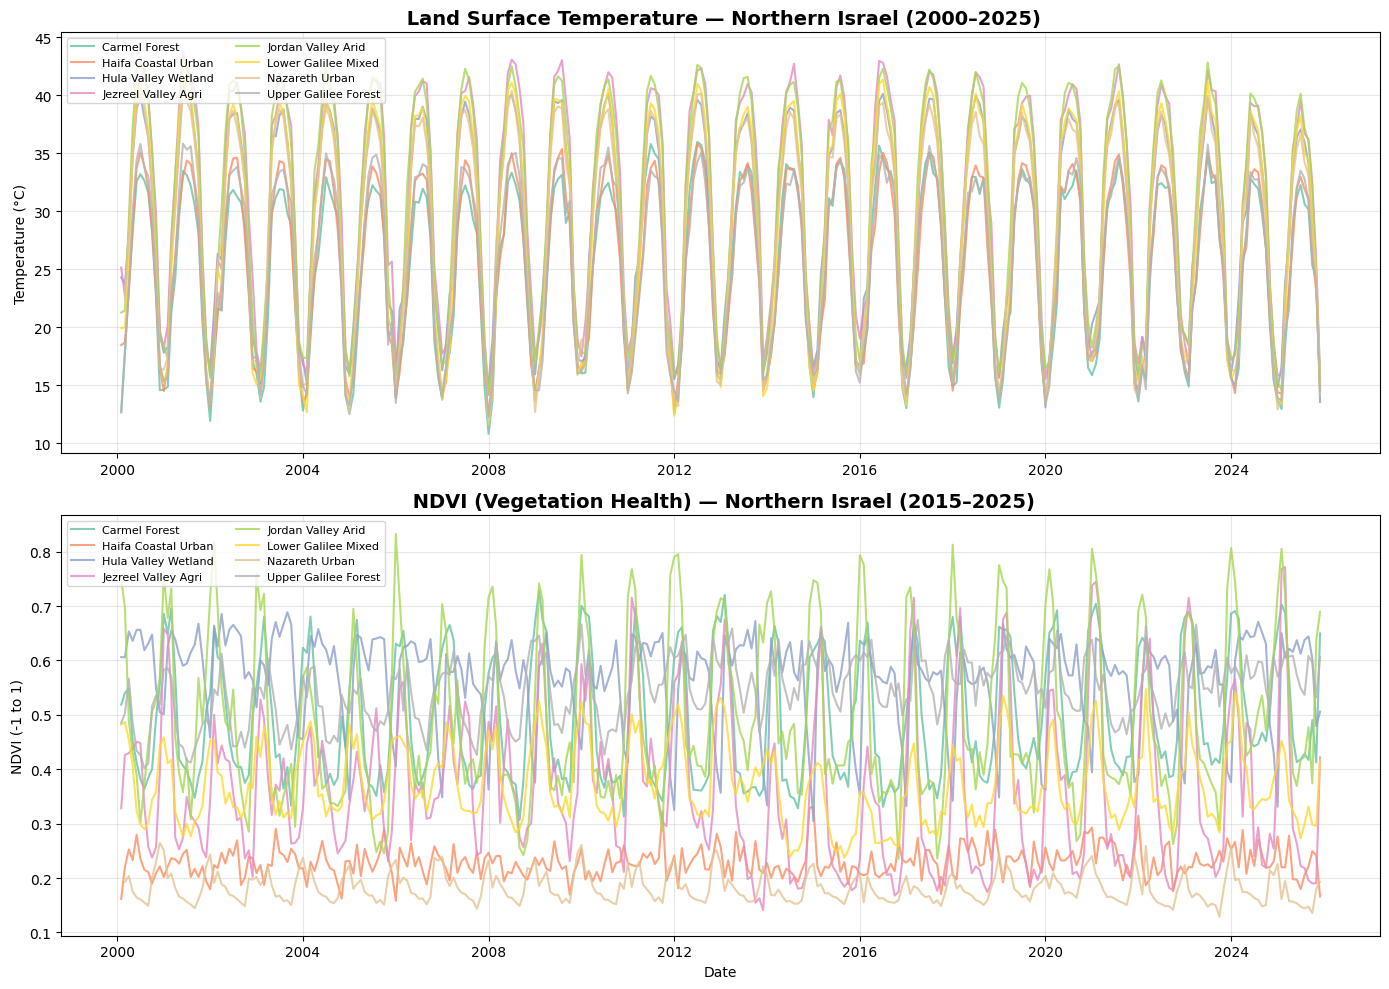

 Time series plot saved!


In [ ]:
# Plot 1: LST over time for all locations
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

colors = plt.cm.Set2(np.linspace(0, 1, len(locations)))

for (name, group), color in zip(master_df.groupby('location'), colors):
    axes[0].plot(group['date'], group['LST_Celsius'],
                 label=name.replace('_', ' '), alpha=0.8, linewidth=1.5, color=color)

axes[0].set_title(' Land Surface Temperature — Northern Israel (2000–2025)',
                   fontsize=14, fontweight='bold')
axes[0].set_ylabel('Temperature (°C)')
axes[0].legend(loc='upper left', fontsize=8, ncol=2)
axes[0].grid(True, alpha=0.3)

# Plot 2: NDVI over time
for (name, group), color in zip(master_df.groupby('location'), colors):
    axes[1].plot(group['date'], group['NDVI'],
                 label=name.replace('_', ' '), alpha=0.8, linewidth=1.5, color=color)

axes[1].set_title(' NDVI (Vegetation Health) — Northern Israel (2015–2025)',
                   fontsize=14, fontweight='bold')
axes[1].set_ylabel('NDVI (-1 to 1)')
axes[1].set_xlabel('Date')
axes[1].legend(loc='upper left', fontsize=8, ncol=2)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('timeseries_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Time series plot saved!')

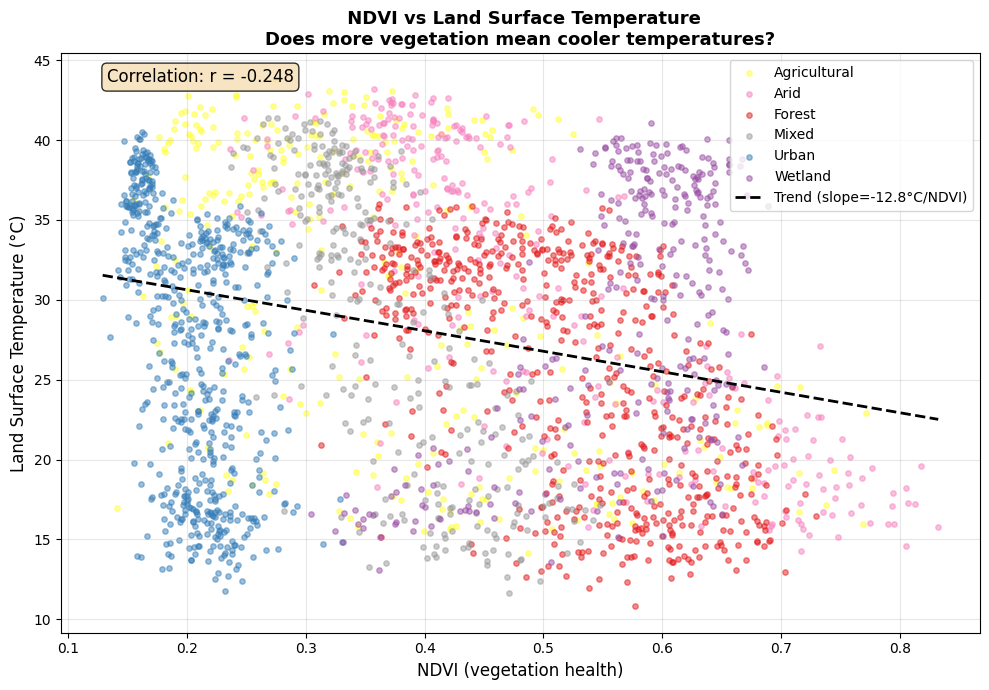

 Scatter plot saved!
 Correlation between NDVI and LST: r = -0.248


In [ ]:
# Plot 2: NDVI vs LST scatter — the core relationship
fig, ax = plt.subplots(figsize=(10, 7))

land_types = master_df['land_type'].unique()
cmap = plt.cm.Set1(np.linspace(0, 1, len(land_types)))
type_colors = dict(zip(land_types, cmap))

for land_type, group in master_df.dropna(subset=['NDVI', 'LST_Celsius']).groupby('land_type'):
    ax.scatter(group['NDVI'], group['LST_Celsius'],
               label=land_type, alpha=0.5, s=15, color=type_colors[land_type])

# Trend line
clean = master_df.dropna(subset=['NDVI', 'LST_Celsius'])
z = np.polyfit(clean['NDVI'], clean['LST_Celsius'], 1)
p = np.poly1d(z)
x_line = np.linspace(clean['NDVI'].min(), clean['NDVI'].max(), 100)
ax.plot(x_line, p(x_line), 'k--', linewidth=2, label=f'Trend (slope={z[0]:.1f}°C/NDVI)')

ax.set_title(' NDVI vs Land Surface Temperature\nDoes more vegetation mean cooler temperatures?',
             fontsize=13, fontweight='bold')
ax.set_xlabel('NDVI (vegetation health)', fontsize=12)
ax.set_ylabel('Land Surface Temperature (°C)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Add correlation
corr = clean['NDVI'].corr(clean['LST_Celsius'])
ax.text(0.05, 0.95, f'Correlation: r = {corr:.3f}',
        transform=ax.transAxes, fontsize=12,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('ndvi_vs_lst_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print(f' Scatter plot saved!')
print(f' Correlation between NDVI and LST: r = {corr:.3f}')

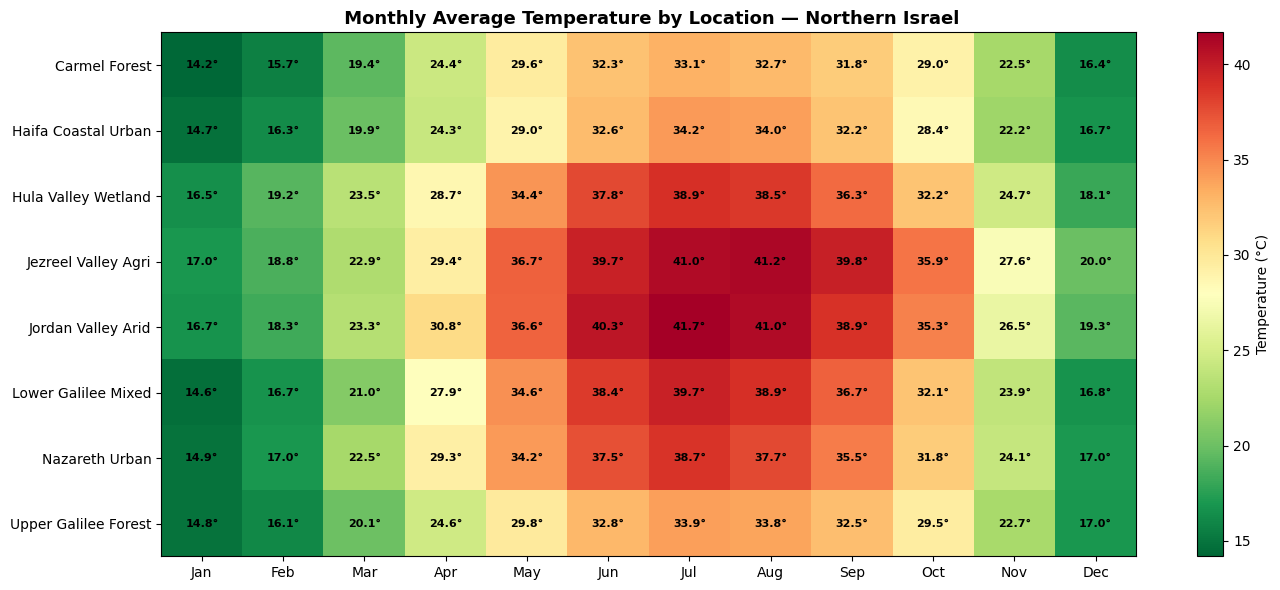

 Monthly heatmap saved!


In [ ]:
# Plot 3: Monthly averages heatmap — seasonal patterns
pivot = master_df.groupby(['location', 'month'])['LST_Celsius'].mean().unstack()
pivot.index = [idx.replace('_', ' ') for idx in pivot.index]
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn_r')
ax.set_xticks(range(12))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

for i in range(len(pivot.index)):
    for j in range(12):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.1f}°', ha='center', va='center', fontsize=8, fontweight='bold')

plt.colorbar(im, ax=ax, label='Temperature (°C)')
ax.set_title(' Monthly Average Temperature by Location — Northern Israel',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('monthly_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Monthly heatmap saved!')

## Step 7 — Export CSV Files

In [ ]:
# Export master dataset
master_df.to_csv('northern_israel_ndvi_lst_2000_2025.csv', index=False)
print(' Main dataset exported: northern_israel_ndvi_lst_2000_2025.csv')

# Export summary statistics
summary = master_df.groupby(['location', 'land_type']).agg(
    avg_LST=('LST_Celsius', 'mean'),
    max_LST=('LST_Celsius', 'max'),
    min_LST=('LST_Celsius', 'min'),
    avg_NDVI=('NDVI', 'mean'),
    max_NDVI=('NDVI', 'max'),
    records=('date', 'count')
).round(3).reset_index()

summary.to_csv('northern_israel_summary_stats.csv', index=False)
print(' Summary stats exported: northern_israel_summary_stats.csv')
print()
print(' Summary Table:')
print(summary.to_string(index=False))

# Download files (works in Colab)
try:
    from google.colab import files
    files.download('northern_israel_ndvi_lst_2015_2025.csv')
    files.download('northern_israel_summary_stats.csv')
    files.download('timeseries_plot.png')
    files.download('ndvi_vs_lst_scatter.png')
    files.download('monthly_heatmap.png')
    print('\n All files downloaded to your computer!')
except:
    print('\n  Not in Colab — files saved in current directory')

 Main dataset exported: northern_israel_ndvi_lst_2000_2025.csv
 Summary stats exported: northern_israel_summary_stats.csv

 Summary Table:
            location    land_type  avg_LST  max_LST  min_LST  avg_NDVI  max_NDVI  records
       Carmel_Forest       Forest   25.114    35.99    10.81     0.496     0.729      311
 Haifa_Coastal_Urban        Urban   25.421    35.84    12.38     0.229     0.331      311
 Hula_Valley_Wetland      Wetland   29.102    41.09    13.09     0.568     0.689      311
 Jezreel_Valley_Agri Agricultural   30.867    43.79    14.16     0.364     0.772      311
  Jordan_Valley_Arid         Arid   30.745    43.19    14.25     0.495     0.832      311
 Lower_Galilee_Mixed        Mixed   28.492    41.37    11.63     0.371     0.548      311
      Nazareth_Urban        Urban   28.428    40.52    11.80     0.182     0.264      310
Upper_Galilee_Forest       Forest   25.660    35.84    12.32     0.546     0.674      311

  Not in Colab — files saved in current directory


## Step 8 — Quick Preview Map

In [ ]:
# Show an interactive map of the region with NDVI overlay
# This is what you can screenshot to send your supervisor!
Map = geemap.Map(center=[32.85, 35.35], zoom=9)

# Add NDVI layer (summer 2024 average)
ndvi_summer = (
    ee.ImageCollection('MODIS/061/MOD13Q1')
    .filterDate('2024-06-01', '2024-08-31')
    .filterBounds(northern_israel)
    .select('NDVI')
    .mean()
    .multiply(0.0001)
)

ndvi_vis = {
    'min': 0, 'max': 0.8,
    'palette': ['#d73027', '#f46d43', '#fdae61', '#fee08b',
                '#d9ef8b', '#a6d96a', '#66bd63', '#1a9850']
}

Map.addLayer(ndvi_summer.clip(northern_israel), ndvi_vis, 'NDVI Summer 2024')

# Add LST layer
lst_summer = (
    ee.ImageCollection('MODIS/061/MOD11A1')
    .filterDate('2024-07-01', '2024-07-31')
    .filterBounds(northern_israel)
    .select('LST_Day_1km')
    .mean()
    .multiply(0.02)
    .subtract(273.15)
)

lst_vis = {
    'min': 20, 'max': 55,
    'palette': ['#313695', '#74add1', '#e0f3f8',
                '#fee090', '#f46d43', '#d73027', '#a50026']
}

Map.addLayer(lst_summer.clip(northern_israel), lst_vis, 'LST July 2024 (°C)')

# Add location markers — fixed: use tooltip instead of popup
for name, point in locations.items():
    coords = point.getInfo()['coordinates']
    Map.add_marker(
        location=[coords[1], coords[0]],
        tooltip=name.replace('_', ' ')   # ← FIXED: was popup=, now tooltip=
    )

Map.addLayerControl()
print(' Map ready — take a screenshot to send your supervisor!')
Map

 Map ready — take a screenshot to send your supervisor!


Map(center=[32.85, 35.35], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

---
## ✅ What You Now Have

| File | Contents |
|---|---|
| `northern_israel_ndvi_lst_2015_2025.csv` | Full dataset — all locations, all months |
| `northern_israel_summary_stats.csv` | Summary statistics per location |
| `timeseries_plot.png` | NDVI + LST over time graphs |
| `ndvi_vs_lst_scatter.png` | NDVI vs temperature relationship |
| `monthly_heatmap.png` | Seasonal temperature patterns |

**Send all of these to your supervisor as proof of data availability!**